In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aabdollahii/wikidata-persian/knowledge_graph_triples.csv


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


In [3]:


# 1. Load the dataset (replace with your Kaggle path if different)
file_path = "/kaggle/input/datasets/aabdollahii/wikidata-persian/knowledge_graph_triples.csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")

# 2. Basic Statistics
total_triples = len(df)
unique_subjects = df["Subject"].nunique()
unique_predicates = df["Predicate"].nunique()
unique_objects = df["Object"].nunique()

all_entities = pd.concat([df["Subject"], df["Object"]]).astype(str)
unique_entities = all_entities.nunique()

print("=== Basic Dataset Statistics ===")
print(f"Total Triples (Facts): {total_triples}")
print(f"Unique Subjects: {unique_subjects}")
print(f"Unique Predicates (Relations): {unique_predicates}")
print(f"Unique Objects: {unique_objects}")
print(f"Total Unique Entities: {unique_entities}\n")

=== Basic Dataset Statistics ===
Total Triples (Facts): 2275010
Unique Subjects: 226414
Unique Predicates (Relations): 15571
Unique Objects: 1015095
Total Unique Entities: 1090676



In [4]:
# 3. Density and Graph-related metrics
# Density = Edges / (Vertices * (Vertices - 1))
if unique_entities > 1:
    graph_density = total_triples / (unique_entities * (unique_entities - 1))
    print(f"Graph Density: {graph_density:.6f}")
else:
    print("Graph Density: N/A")

Graph Density: 0.000002


In [5]:
# 4. Top Predicates (Relations Distribution)
top_predicates = df["Predicate"].value_counts().head(10)
print("\n=== Top 10 Most Frequent Predicates ===")
print(top_predicates)

# 5. Top Entities (Subjects & Objects combined)
top_entities = all_entities.value_counts().head(10)
print("\n=== Top 10 Most Frequent Entities ===")
print(top_entities)

# 6. Check for Missing Values
missing_values = df.isnull().sum()
print("\n=== Missing Values Per Column ===")
print(missing_values)


=== Top 10 Most Frequent Predicates ===
Predicate
نام             97745
استان           86438
شهرستان         83211
تصویر           62349
بخش             60490
نام رسمی        55756
جمعیت           55528
دهستان          54759
کد آماری        45048
اندازه تصویر    30484
Name: count, dtype: int64

=== Top 10 Most Frequent Entities ===
آری            26879
250            23411
بخش مرکزی      16614
مرکزی          12913
yes            12789
#FFFFC0        11698
مه ۱۴, ۲۰۰۸    10715
ایران          10089
انگلیسی         8439
دوره قاجار      7904
Name: count, dtype: int64

=== Missing Values Per Column ===
Subject        0
Predicate      4
Object       119
dtype: int64


/tmp/ipykernel_16/2198860616.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_16/2198860616.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


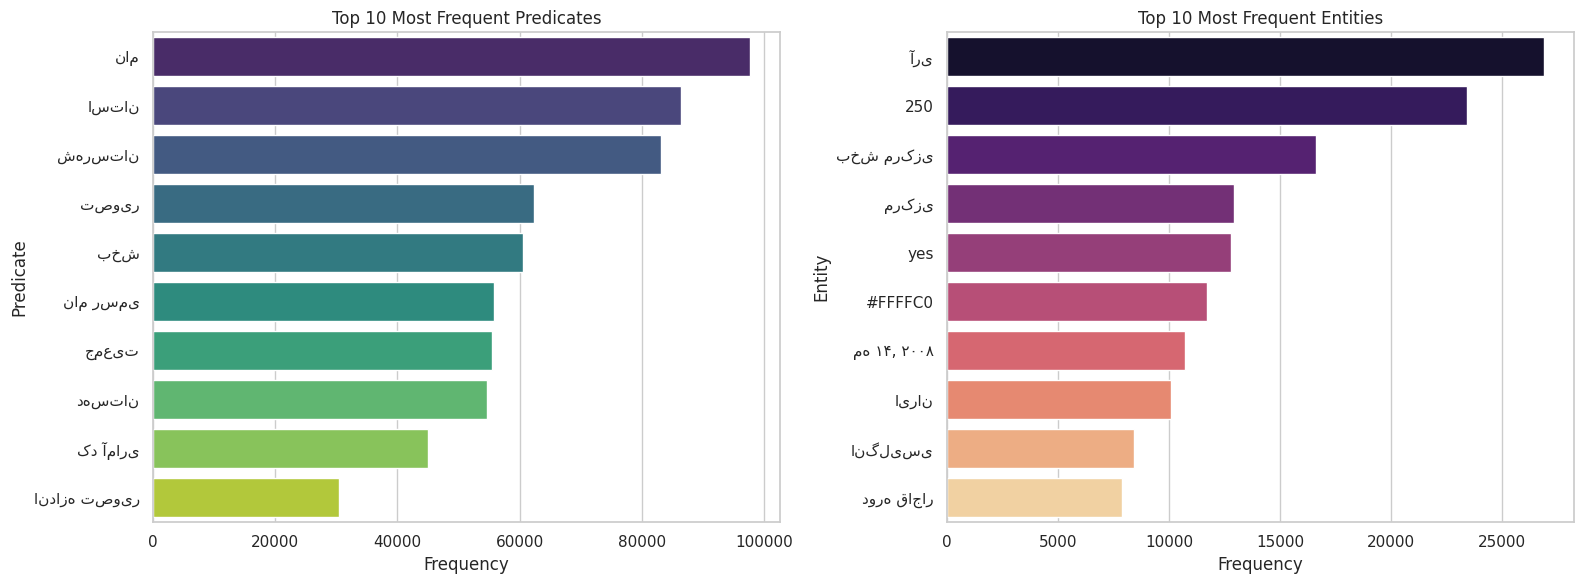

In [6]:
# 7. Visualization
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Top Predicates
sns.barplot(
    x=top_predicates.values,
    y=top_predicates.index,
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("Top 10 Most Frequent Predicates")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Predicate")

# Plot Top Entities
sns.barplot(
    x=top_entities.values,
    y=top_entities.index,
    ax=axes[1],
    palette="magma",
)
axes[1].set_title("Top 10 Most Frequent Entities")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Entity")

plt.tight_layout()
plt.show()

# Deeper analysis

=== BASIC SHAPE ===
Rows: 2274887
Columns: ['Subject', 'Predicate', 'Object']

=== DUPLICATES ===
Duplicate rows: 29387
Duplicate ratio: 0.0129

=== NULLS AFTER DROP ===
Subject      0
Predicate    0
Object       0
dtype: int64

=== UNIQUE COUNTS ===
Unique subjects: 226414
Unique predicates: 15571
Unique objects: 1015095
Unique entities (subject+object): 1090675

=== SELF LOOPS ===
Self-loop triples: 151039
Self-loop ratio: 0.0664

=== OBJECT ALSO APPEARS AS SUBJECT ===
Count: 396587
Ratio: 0.1743

=== PREDICATE COVERAGE ===
Top 20 predicates:
Predicate
نام              97745
استان            86438
شهرستان          83211
تصویر            62349
بخش              60490
نام رسمی         55756
جمعیت            55528
دهستان           54759
کد آماری         45048
اندازه تصویر     30484
عنوان            29718
روی‌نقشه         27361
شماره ثبت        22853
ملیت             22351
کاربری           22045
زبان             21000
پیشه             19610
دیرینگی          18439
دوره ساخت اثر    18274
کش

,Subject,Predicate,Object,subject_len,predicate_len,object_len,object_type
0,سعدی,نام,سعدی شیرازی,4,3,11,text
25,جامی,نام,عبدالرحمان جامی,4,3,15,text
44,عماد خراسانی,نام,عماد خراسانی,12,3,12,text
127,آنتوان دو سنت‌اگزوپری,نام,آنتوان دو سنت‌اگزوپری,21,3,21,text
149,اریک کلپتون,نام,اریک کلپتون,11,3,11,text



--- Predicate: استان ---


,Subject,Predicate,Object,subject_len,predicate_len,object_len,object_type
314,نهاوند,استان,همدان,6,5,5,text
353,خمین,استان,مرکزی,4,5,5,text
707,تبریز,استان,آذربایجان شرقی,5,5,14,text
742,پاوه,استان,کرمانشاه,4,5,8,text
844,بابل (مازندران),استان,مازندران,15,5,8,text



--- Predicate: شهرستان ---


...


--- Predicate: تصویر ---


,Subject,Predicate,Object,subject_len,predicate_len,object_len,object_type
1,سعدی,تصویر,Sadi in a Rose garden.jpg,4,5,25,text
45,عماد خراسانی,تصویر,Emad Khorasani.jpg,12,5,18,text
128,آنتوان دو سنت‌اگزوپری,تصویر,11exupery-inline1-500 (cropped).jpg,21,5,35,text
150,اریک کلپتون,تصویر,Eric Clapton 2.jpg,11,5,18,text
231,ناصرخسرو,تصویر,"Stamps of Tajikistan, 030-03.jpg",8,5,32,text



--- Predicate: بخش ---


,Subject,Predicate,Object,subject_len,predicate_len,object_len,object_type
316,نهاوند,بخش,مرکزی,6,3,5,text
339,استان مرکزی,بخش,۲۶ دهستان= ۶۴ شهر=۳۵,11,3,20,text
355,خمین,بخش,مرکزی,4,3,5,text
709,تبریز,بخش,مرکزی,5,3,5,text
744,پاوه,بخش,مرکزی,4,3,5,text


/tmp/ipykernel_16/3487474691.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_predicates.values, y=top_predicates.index, ax=axes[0, 0], palette="viridis")
/tmp/ipykernel_16/3487474691.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=obj_type_counts.values, y=obj_type_counts.index, ax=axes[0, 1], palette="magma")
/tmp/ipykernel_16/3487474691.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_entity_counts.values, y=top_entity_counts.index, ax=axes[1, 1], palette="cubehelix")


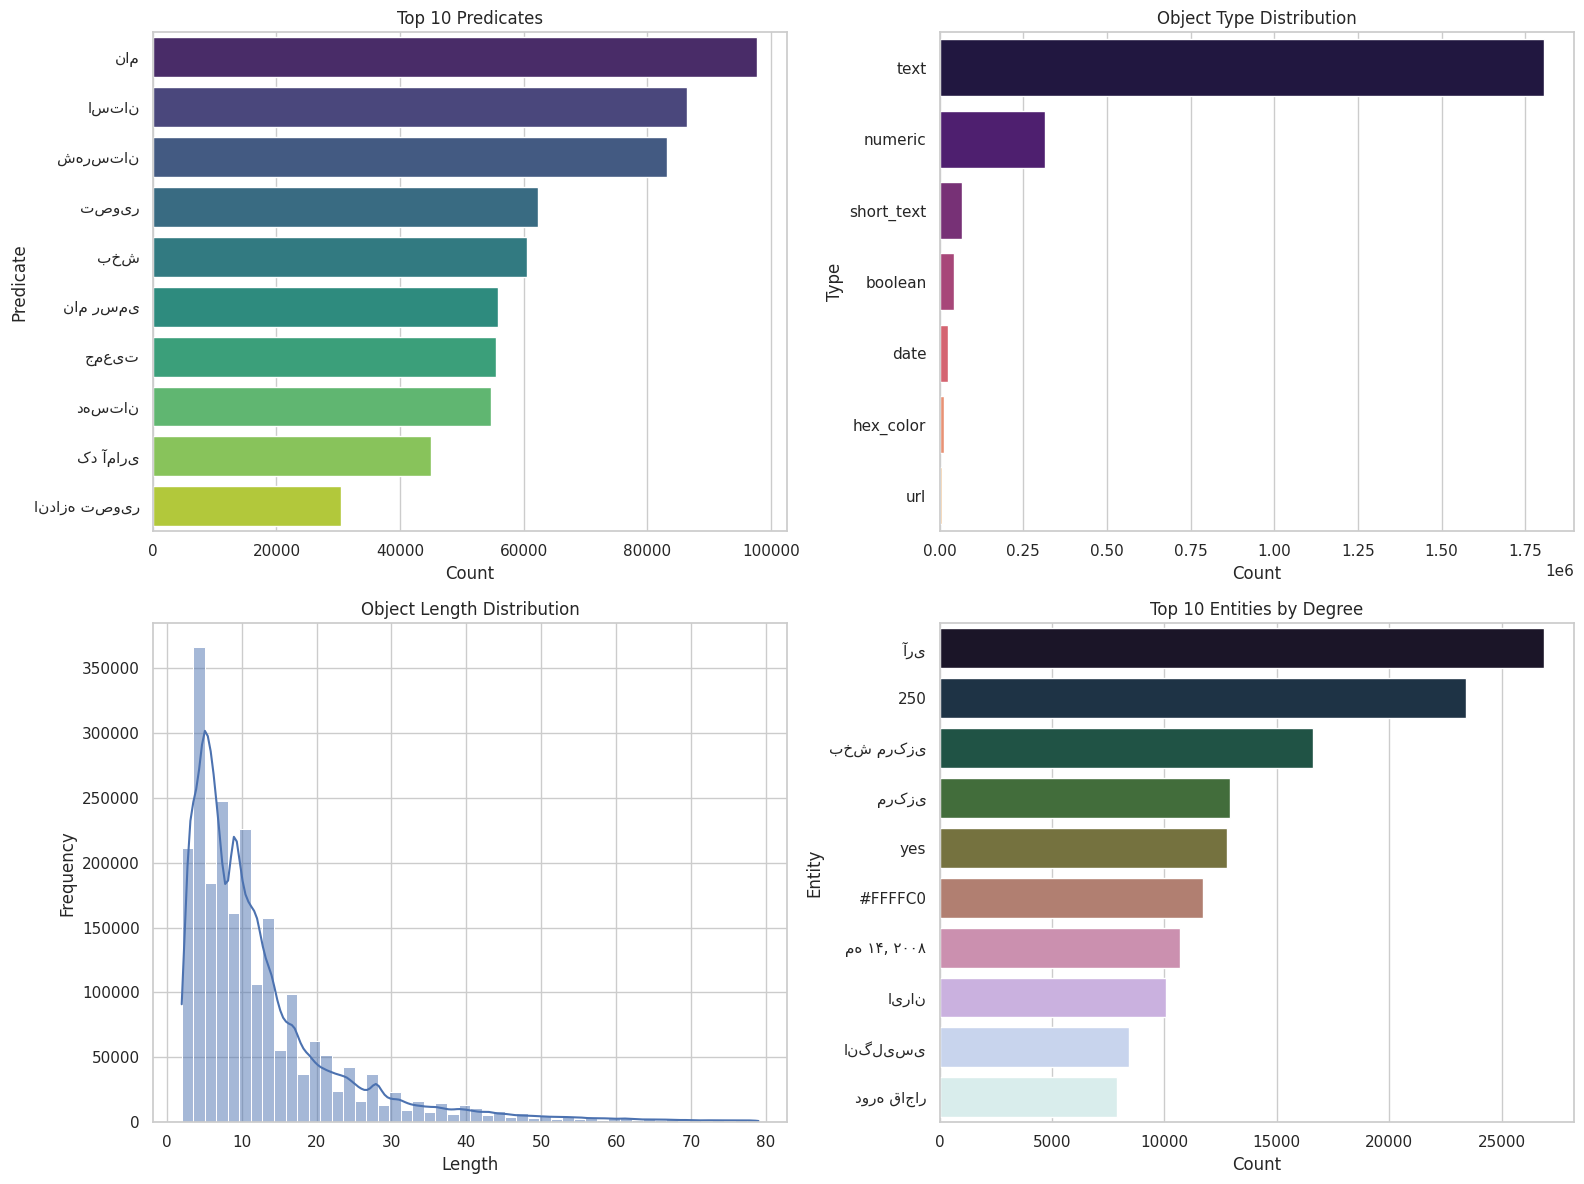

In [7]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


df = df.dropna(subset=["Subject", "Predicate", "Object"]).copy()
for col in ["Subject", "Predicate", "Object"]:
    df[col] = df[col].astype(str).str.strip()

print("=== BASIC SHAPE ===")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print()

print("=== DUPLICATES ===")
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)
print("Duplicate ratio:", round(dup_count / len(df), 4))
print()

print("=== NULLS AFTER DROP ===")
print(df.isnull().sum())
print()

# Unique counts
unique_subjects = df["Subject"].nunique()
unique_predicates = df["Predicate"].nunique()
unique_objects = df["Object"].nunique()
unique_entities = pd.concat([df["Subject"], df["Object"]]).nunique()

print("=== UNIQUE COUNTS ===")
print("Unique subjects:", unique_subjects)
print("Unique predicates:", unique_predicates)
print("Unique objects:", unique_objects)
print("Unique entities (subject+object):", unique_entities)
print()

# Self-loops
self_loops = (df["Subject"] == df["Object"]).sum()
print("=== SELF LOOPS ===")
print("Self-loop triples:", self_loops)
print("Self-loop ratio:", round(self_loops / len(df), 4))
print()

# How often objects appear as subjects
subject_set = set(df["Subject"])
object_in_subject = df["Object"].isin(subject_set).sum()
print("=== OBJECT ALSO APPEARS AS SUBJECT ===")
print("Count:", object_in_subject)
print("Ratio:", round(object_in_subject / len(df), 4))
print()

# Predicate frequency
pred_counts = df["Predicate"].value_counts()
print("=== PREDICATE COVERAGE ===")
print("Top 20 predicates:")
print(pred_counts.head(20))
print()

# Coverage by top predicates
topk = [10, 20, 50, 100]
for k in topk:
    coverage = pred_counts.head(k).sum() / len(df)
    print(f"Top {k} predicates coverage: {coverage:.4f}")
print()

# Entity degree
entity_counter = Counter(df["Subject"]).copy()
entity_counter.update(df["Object"])

top_entities = pd.Series(entity_counter).sort_values(ascending=False)
print("=== TOP 20 ENTITIES BY DEGREE ===")
print(top_entities.head(20))
print()

# Subject/object length stats
df["subject_len"] = df["Subject"].str.len()
df["predicate_len"] = df["Predicate"].str.len()
df["object_len"] = df["Object"].str.len()

print("=== STRING LENGTH STATS ===")
print(df[["subject_len", "predicate_len", "object_len"]].describe())
print()

# Heuristic object type detection
hex_pattern = re.compile(r"^#([A-Fa-f0-9]{3}|[A-Fa-f0-9]{6})$")
url_pattern = re.compile(r"^https?://")
num_pattern = re.compile(r"^[+-]?\d+([.,]\d+)?$")
date_patterns = [
    re.compile(r"^\d{1,2}\s+\w+\s+\d{4}$"),  # e.g. 1 Jan 2020
    re.compile(r"^\d{4}-\d{2}-\d{2}$"),
]

def classify_object(x):
    s = str(x).strip()
    sl = s.lower()
    if sl in {"yes", "no", "true", "false", "آری", "نه"}:
        return "boolean"
    if hex_pattern.match(s):
        return "hex_color"
    if url_pattern.match(sl):
        return "url"
    if num_pattern.match(s):
        return "numeric"
    for p in date_patterns:
        if p.match(s):
            return "date"
    if len(s) <= 3 and s.isalpha():
        return "short_text"
    return "text"

df["object_type"] = df["Object"].apply(classify_object)

print("=== OBJECT TYPE DISTRIBUTION ===")
print(df["object_type"].value_counts(normalize=True).round(4))
print()

# Predicates by object type
print("=== TOP PREDICATES PER OBJECT TYPE ===")
for t in df["object_type"].value_counts().index:
    subset = df[df["object_type"] == t]
    print(f"\n--- {t} ({len(subset)}) ---")
    print(subset["Predicate"].value_counts().head(10))

# Rows with noisy-looking objects
noise_predicates = {
    "تصویر", "اندازه تصویر", "کد آماری", "لوگو", "پرچم", "جایزه", "امضا",
    "نقشه", "عرض تصویر", "ارتفاع تصویر", "اندازه", "آرم"
}
noise_like = df[
    df["Predicate"].isin(noise_predicates) |
    df["object_type"].isin(["boolean", "hex_color", "url"])
]
print("\n=== NOISE-LIKE ROWS ===")
print("Count:", len(noise_like))
print("Ratio:", round(len(noise_like) / len(df), 4))
print()

# Sample rows from top predicates
print("=== SAMPLE ROWS FROM TOP 5 PREDICATES ===")
for pred in pred_counts.head(5).index:
    print(f"\n--- Predicate: {pred} ---")
    display(df[df["Predicate"] == pred].head(5))

# Visualization
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Top predicates
top_predicates = pred_counts.head(10)
sns.barplot(x=top_predicates.values, y=top_predicates.index, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Top 10 Predicates")
axes[0, 0].set_xlabel("Count")
axes[0, 0].set_ylabel("Predicate")

# 2) Object types
obj_type_counts = df["object_type"].value_counts()
sns.barplot(x=obj_type_counts.values, y=obj_type_counts.index, ax=axes[0, 1], palette="magma")
axes[0, 1].set_title("Object Type Distribution")
axes[0, 1].set_xlabel("Count")
axes[0, 1].set_ylabel("Type")

# 3) Object lengths
sns.histplot(df["object_len"], bins=50, ax=axes[1, 0], kde=True)
axes[1, 0].set_title("Object Length Distribution")
axes[1, 0].set_xlabel("Length")
axes[1, 0].set_ylabel("Frequency")

# 4) Degree distribution (top entities)
top_entity_counts = top_entities.head(10)
sns.barplot(x=top_entity_counts.values, y=top_entity_counts.index, ax=axes[1, 1], palette="cubehelix")
axes[1, 1].set_title("Top 10 Entities by Degree")
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_ylabel("Entity")

plt.tight_layout()
plt.show()


In [8]:
import re

def clean_knowledge_graph_df(df, output_path=None):
    print("Starting cleaning on existing DataFrame...")
    initial_rows = len(df)
    print(f"Initial row count: {initial_rows:,}")
    
    # Ensure required columns exist
    required_cols = ["Subject", "Predicate", "Object"]
    for c in required_cols:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")
    
    # 1. Drop NaN values
    df = df.dropna(subset=["Subject", "Predicate", "Object"]).copy()
    for col in ["Subject", "Predicate", "Object"]:
        df[col] = df[col].astype(str).str.strip()
    
    # 2. Remove self-loops (Subject == Object)
    before_self = len(df)
    df = df[df["Subject"] != df["Object"]]
    after_self = len(df)
    print(f"Rows after removing self-loops: {after_self:,} (Removed: {before_self - after_self:,})")
    
    # 3. Filter out noise predicates
    noise_predicates = {
        "تصویر", "اندازه تصویر", "کد آماری", "لوگو", "پرچم", "جایزه", "امضا",
        "نقشه", "عرض تصویر", "ارتفاع تصویر", "اندازه", "آرم", "bgcolour",
        "رنگ", "رنگ پس‌زمینه", "hex", "bg", "پس‌زمینه عنوان", "کد رنگ",
        "color", "mapframe-geomask-stroke-color", "titlebar", "روی‌نقشه",
        "سیاره کوچک", "ویکی‌خبر", "دورنما", "ویکی‌گونه", "ویکی‌نسک",
        "ویکی‌واژه", "توضیح تصویر", "عرض جغرافیایی", "طول جغرافیایی"
    }
    before_pred = len(df)
    df = df[~df["Predicate"].isin(noise_predicates)]
    after_pred = len(df)
    print(f"Rows after filtering noise predicates: {after_pred:,} (Removed: {before_pred - after_pred:,})")
    
    # 4. Filter Object patterns (URLs, Hex colors)
    hex_pattern = re.compile(r"^#([A-Fa-f0-9]{3}|[A-Fa-f0-9]{6})$")
    url_pattern = re.compile(r"^https?://")
    
    def is_noise_object(val):
        val_str = str(val).strip()
        if hex_pattern.match(val_str):
            return True
        if url_pattern.match(val_str.lower()):
            return True
        return False
    
    before_obj = len(df)
    df = df[~df["Object"].apply(is_noise_object)]
    after_obj = len(df)
    print(f"Rows after filtering noise objects (URL/Hex): {after_obj:,} (Removed: {before_obj - after_obj:,})")
    
    # 5. Length thresholds
    # These can be tuned; right now conservative values:
    df = df[
        (df["Subject"].str.len().between(2, 40)) &
        (df["Predicate"].str.len().between(2, 30)) &
        (df["Object"].str.len().between(2, 60))
    ]
    final_rows = len(df)
    print(f"Final rows after length filtering: {final_rows:,} (Removed: {after_obj - final_rows:,})")
    print(f"Total rows removed: {initial_rows - final_rows:,} "
          f"({((initial_rows - final_rows) / initial_rows) * 100:.2f}%)")
    
    # Optional saving
    if output_path is not None:
        df.to_csv(output_path, index=False, encoding="utf-8-sig")
        print(f"Cleaned dataset saved to: {output_path}")
    
    return df

# استفاده:
# فرض بر این است که df را قبلاً ساخته‌ای (با read_csv یا هر روش دیگر)
cleaned_df = clean_knowledge_graph_df(df, output_path="cleaned_knowledge_graph.csv")


Starting cleaning on existing DataFrame...
Initial row count: 2,274,887
Rows after removing self-loops: 2,123,848 (Removed: 151,039)
Rows after filtering noise predicates: 1,893,817 (Removed: 230,031)
Rows after filtering noise objects (URL/Hex): 1,887,020 (Removed: 6,797)
Final rows after length filtering: 1,848,357 (Removed: 38,663)
Total rows removed: 426,530 (18.75%)
Cleaned dataset saved to: cleaned_knowledge_graph.csv
